In [143]:
import pandas as pd
import numpy as np

In [144]:
df = pd.read_csv("dataset.csv")

In [145]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [146]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [147]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [148]:
df = df.drop_duplicates()

In [149]:
df.isnull().sum()

id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

In [150]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

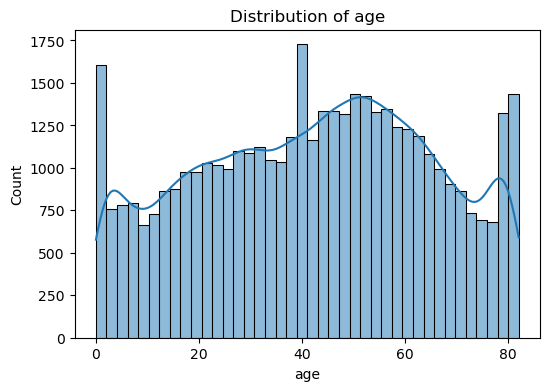

<Figure size 640x480 with 0 Axes>

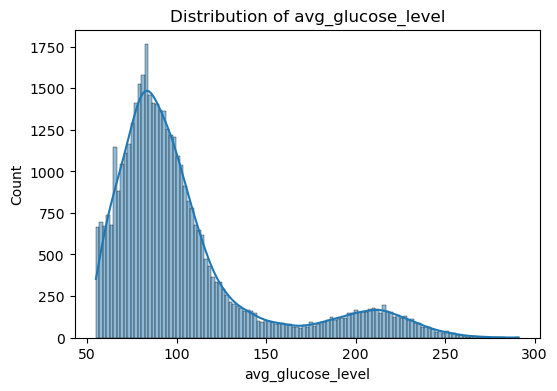

<Figure size 640x480 with 0 Axes>

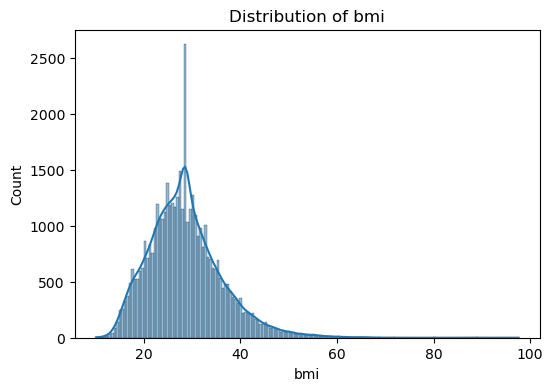

<Figure size 640x480 with 0 Axes>

In [152]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.tight_layout()

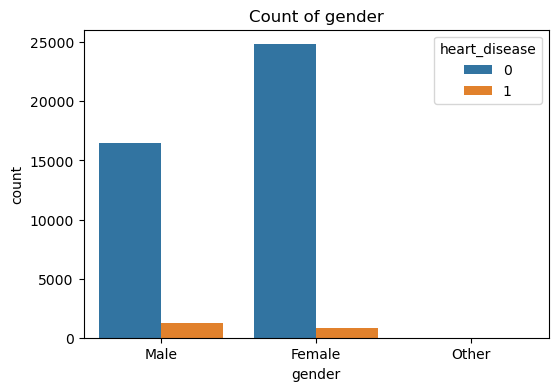

<Figure size 640x480 with 0 Axes>

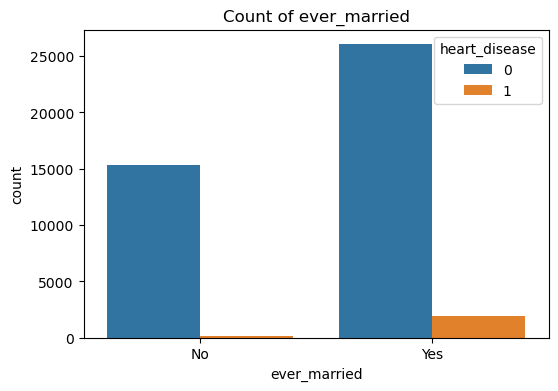

<Figure size 640x480 with 0 Axes>

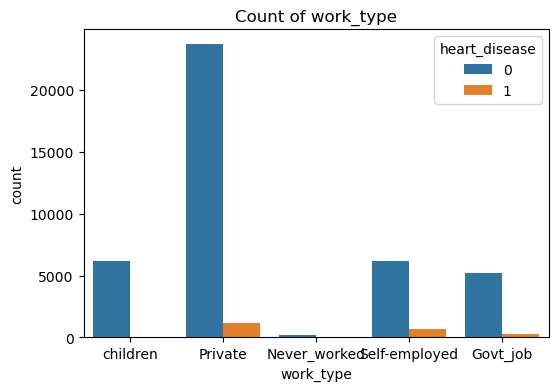

<Figure size 640x480 with 0 Axes>

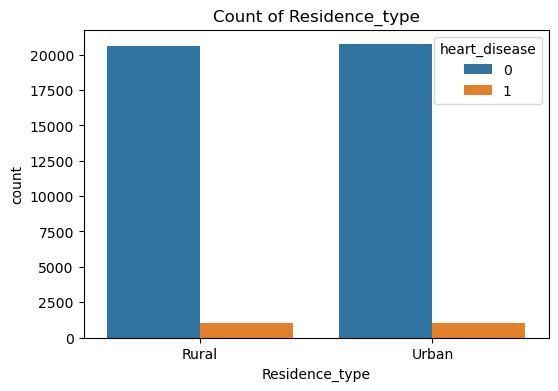

<Figure size 640x480 with 0 Axes>

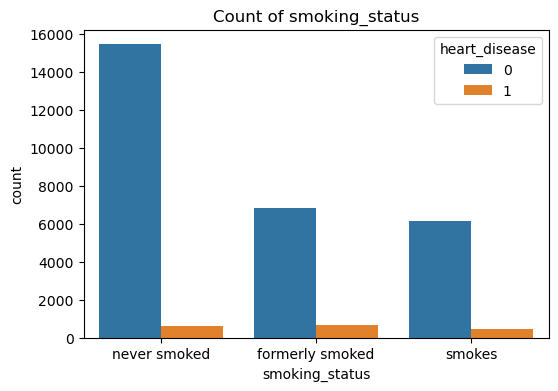

<Figure size 640x480 with 0 Axes>

In [153]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'] 
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x = df[col],hue = df['heart_disease'])
    plt.title(f"Count of {col}")
    plt.show()
    plt.tight_layout()

<Axes: >

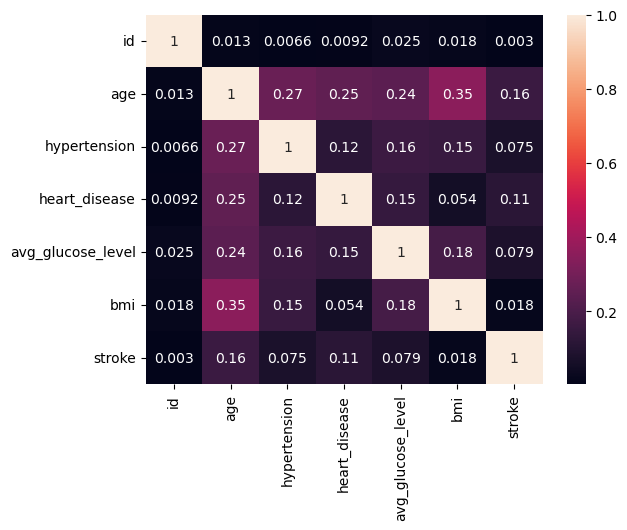

In [154]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [155]:
 df = df.drop('id', axis=1)

In [156]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [157]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [158]:
categorical_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [159]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,3.0,0,0,0,4,0,95.12,18.0,3,0
1,1,58.0,1,0,1,2,1,87.96,39.2,1,0
2,0,8.0,0,0,0,2,1,110.89,17.6,3,0
3,0,70.0,0,0,1,2,0,69.04,35.9,0,0
4,1,14.0,0,0,0,1,0,161.28,19.1,3,0


In [160]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

In [161]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [162]:
X_scaled

array([[ 1.20108119, -1.74151677, -0.32129564, ..., -1.38846925,
         1.28640708, -0.13554685],
       [ 1.20108119,  0.700823  ,  3.11239826, ...,  1.38714994,
        -0.53968634, -0.13554685],
       [-0.83084068, -1.51948588, -0.32129564, ..., -1.44083942,
         1.28640708, -0.13554685],
       ...,
       [-0.83084068,  1.76657127,  3.11239826, ...,  0.03861798,
        -1.45273305, -0.13554685],
       [ 1.20108119, -0.0984882 , -0.32129564, ...,  0.60159734,
        -0.53968634, -0.13554685],
       [-0.83084068,  1.76657127, -0.32129564, ..., -1.04806312,
        -0.53968634, -0.13554685]], shape=(43400, 10))

In [163]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( 
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)  

In [190]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [191]:
y_train.value_counts()

heart_disease
0    33070
1    33070
Name: count, dtype: int64

In [192]:
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [193]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

In [194]:
accuracy_score(y_test,y_pred)

0.9006912442396313

In [169]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

df_metrics = pd.DataFrame(metrics, index=["Score"])
print(df_metrics)


       Accuracy  Precision    Recall  F1-Score
Score  0.900691   0.170088  0.281553  0.212066


In [187]:

from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=10, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)


In [188]:
accuracy_score(y_test,y_pred)

0.8009216589861751

In [189]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

df_metrics = pd.DataFrame(metrics, index=["Score"])
print(df_metrics)


       Accuracy  Precision    Recall  F1-Score
Score  0.800922       0.15  0.684466  0.246073
